In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "6"
from astropy.io import fits
import pylab
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
import sys
sys.path.append('/home/javva/spt3g_software/scratch/javva/sptslim')
sys.path.append('/home/javva/spt3g_software/build')
from spt3g import core, maps
from spt3g.mapspectra import curved_sky as cs
import glob
import scipy.stats as stats
import pickle

import scipy

In [2]:
# show maps available 
dir = '/sptlocal/user/creichardt/bb2020/'

files = glob.glob(dir + '*')
for f in files:
    print(f)

/sptlocal/user/creichardt/bb2020/puremask_0p5medwt_100mJy_30arcmin.npz
/sptlocal/user/creichardt/bb2020/c2mask_0p5medwt_120arcmin.npz
/sptlocal/user/creichardt/bb2020/circletest_puremask_0p5medwt_radius480_240arcmin.npz
/sptlocal/user/creichardt/bb2020/circletest_c2puremask_0p5medwt_radius960_120arcmin.npz
/sptlocal/user/creichardt/bb2020/puremask_0p5medwt_250mJy_180arcmin.npz
/sptlocal/user/creichardt/bb2020/circletest_puremask_0p5medwt_radius960_480arcmin.npz
/sptlocal/user/creichardt/bb2020/border_lines_0p5medwt.npz
/sptlocal/user/creichardt/bb2020/circletest_puremask_0p5medwt_radius1800_240arcmin.npz
/sptlocal/user/creichardt/bb2020/circletest_c2puremask_0p5medwt_radius2400_240arcmin.npz
/sptlocal/user/creichardt/bb2020/distance_xy_0p5medwt.npz
/sptlocal/user/creichardt/bb2020/distance_0p5medwt.npz
/sptlocal/user/creichardt/bb2020/mask_badpixels_180arcmin.npz
/sptlocal/user/creichardt/bb2020/circletest_c2puremask_0p5medwt_radius960_240arcmin.npz
/sptlocal/user/creichardt/bb2020/pur

#### The list of masks that I want to look at are: 


In [ ]:
#### change the mask location here #####
mask_name = '/sptlocal/user/creichardt/bb2020/puremask_0p5medwt_120arcmin.npz'
########################################

# loads the mask and sets NaN values to 0
import healpy as hp
mask= np.load(mask_name)['mask']
mask[np.isnan(mask)] = 0


In [ ]:
import datetime
import pymaster as nmt

# this function 
#Computes the full-sky angular power spectra of two masked fields \
#    (f1 and f2) without aiming to deconvolve the mode-coupling matrix. \
#    Effectively, this is equivalent to calling the usual HEALPix \
#    anafast routine on the masked and contaminant-cleaned maps.
def compute_master(f_a, f_b, wsp):
    cl_coupled = nmt.compute_coupled_cell(f_a, f_b) # computes the pseudo-Cl
    cl_decoupled = wsp.decouple_cell(cl_coupled) # estimate of true cl
    return cl_decoupled

def run_namaster(dmap,mask,return_nonpureB=False):
    '''                                                                                                                                                                                          
    Note: Only works for apodized mask.                                                                                                                                                          
    '''
    print('1.', datetime.datetime.now())
    b = nmt.NmtBin.from_nside_linear(hp.npix2nside(mask.shape[0]), 10)
    print('2.', datetime.datetime.now())

    if return_nonpureB == False:
        print('3.', datetime.datetime.now())

        f2yp0 = nmt.NmtField(mask, [dmap[1], dmap[2]], purify_e=False, purify_b=True)
        print('4.', datetime.datetime.now())

        w_yp  = nmt.NmtWorkspace()
        w_yp.compute_coupling_matrix(f2yp0, f2yp0, b)
        print('5.', datetime.datetime.now())

        clyp  = compute_master(f2yp0, f2yp0, w_yp)
        print('6#----finished computing namaster----', datetime.datetime.now())
        return b.get_effective_ells(), clyp

    if return_nonpureB == True:
        f2np0 = nmt.NmtField(mask, [dmap[1], dmap[2]])
        f2yp0 = nmt.NmtField(mask, [dmap[1], dmap[2]], purify_e=False, purify_b=True)

        w_np  = nmt.NmtWorkspace()
        w_np.compute_coupling_matrix(f2np0, f2np0, b)
        w_yp  = nmt.NmtWorkspace()
        w_yp.compute_coupling_matrix(f2yp0, f2yp0, b)

        clnp  = compute_master(f2np0, f2np0, w_np)
        clyp  = compute_master(f2yp0, f2yp0, w_yp)
        print('#----finished computing namaster----')
        return b.get_effective_ells(), clyp, clnp


# i guess load the mid-l g3 coadd?  
m1 = list(core.G3File('/big_scratch/javva/p2/high_fg_sims/coadd_mocks/40_stub_coadd_high_fg_sims_90GHz_0028.g3'))[0]
maps.RemoveWeights(m1,zero_nans=True)
output = run_namaster([m1['T'],m1['Q'],-1*m1['U']], mask)
with open('mask_test_%s.pkl'%mask_name.split('/')[-1], 'wb') as f:
        pickle.dump(output, f)


In [6]:
def cl_to_dl(l,cl):
    return(cl*(l*(l+1.))/(2*np.pi))
ps_dir = {}
ps_dir[mask_name] = {}
with open('mask_test_%s.pkl'%mask_name.split('/')[-1], 'rb') as handle:
    sf = pickle.load(handle)
ells = sf[0]
ps_dir[mask_name]['ells']  = sf[0]
ps_dir[mask_name]['EE'] = cl_to_dl(ells,sf[1][0])/core.G3Units.uK**2
ps_dir[mask_name]['BB'] = cl_to_dl(ells,sf[1][3])/core.G3Units.uK**2


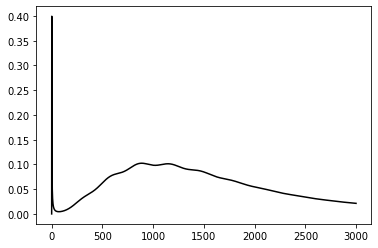

In [ ]:
#get input theory curves
with open('/home/javva/spt3g_software/simulations/scripts/cls_out_bktimes2_bk_alphatimes2_beta_1.6.pkl', 'rb') as handle:
    clsPAaB = pickle.load(handle)
with open('/home/javva/spt3g_software/simulations/scripts/cls_out.pkl', 'rb') as handle:
    cls = pickle.load(handle)
k = 'GD' # dust model type
k1 = 'cmb'
b = '90GHz'
idx = 2  # picks BB spectrum
old_binned = cl_to_dl(np.arange(0,len(clsPAaB[b][k][idx][:5001]),1),(clsPAaB[b][k][idx][:5001]+cls[k1][idx])/core.G3Units.uK**2)
plt.plot(old_binned[:2999],'k-',label = '%s Theory'%b)
print("The theoretical BB power spectrum with CMB BB + dust foreground BB ")

Text(0.5, 1.0, 'Testing Polspice with Different Masks')

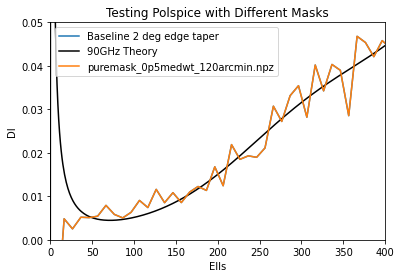

In [9]:
#put it all on a plot
def cl_to_dl(l,cl):
    return(cl*(l*(l+1.))/(2*np.pi))
means = []
first_time = True
baseline_file = '/sptgrid/user/javva/p2/High_fg_sims_namaster_90GHz_delta_ell_10_bins_puremask_0p5medwt_120arcmin/High_fg_sims_namaster_90GHz_delta_ell_10_bins_puremask_0p5medwt_120arcmin0028.pkl'
with open(baseline_file, 'rb') as handle:
    output4 = pickle.load(handle)
ells_baseline = output4[0]
dlBB_baseline = cl_to_dl(ells_baseline,output4[1][3]/core.G3Units.uK**2)
dlEE_baseline = cl_to_dl(ells_baseline,output4[1][0]/core.G3Units.uK**2)

plt.plot(ells_baseline,dlBB_baseline, label = 'Baseline 2 deg edge taper')
plt.plot(old_binned[:2999],'k-',label = '%s Theory'%b)
plt.plot(ps_dir[mask_name]['ells'],ps_dir[mask_name]['BB'], label = mask_name.split('/')[-1])
#plt.semilogy()
plt.ylim(0,0.05)
plt.legend()
plt.legend()
plt.xlabel('Ells')
plt.xlim(0,400)
plt.ylabel('Dl')
plt.title("Testing Polspice with Different Masks")